# Парсинг логов скрипта мониторинга

Парсим логи скрипта, мониторящего потребление памяти топ 10 (или скольки-то еще) процессов

In [24]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [41]:
envfilepath = None
if envfilepath is None:
    vardirpath = os.getcwd()    
    #print("getcwd:", vardirpath)
    print(os.curdir)
    print(dir(os))
    print(dir(os.path))
    #print(os.path.dirname(vardirpath))

.
['CLD_CONTINUED', 'CLD_DUMPED', 'CLD_EXITED', 'CLD_KILLED', 'CLD_STOPPED', 'CLD_TRAPPED', 'DirEntry', 'EX_CANTCREAT', 'EX_CONFIG', 'EX_DATAERR', 'EX_IOERR', 'EX_NOHOST', 'EX_NOINPUT', 'EX_NOPERM', 'EX_NOUSER', 'EX_OK', 'EX_OSERR', 'EX_OSFILE', 'EX_PROTOCOL', 'EX_SOFTWARE', 'EX_TEMPFAIL', 'EX_UNAVAILABLE', 'EX_USAGE', 'F_LOCK', 'F_OK', 'F_TEST', 'F_TLOCK', 'F_ULOCK', 'GenericAlias', 'Mapping', 'MutableMapping', 'NGROUPS_MAX', 'O_ACCMODE', 'O_APPEND', 'O_ASYNC', 'O_CLOEXEC', 'O_CREAT', 'O_DIRECTORY', 'O_DSYNC', 'O_EXCL', 'O_EXLOCK', 'O_NDELAY', 'O_NOCTTY', 'O_NOFOLLOW', 'O_NONBLOCK', 'O_RDONLY', 'O_RDWR', 'O_SHLOCK', 'O_SYNC', 'O_TRUNC', 'O_WRONLY', 'POSIX_SPAWN_CLOSE', 'POSIX_SPAWN_DUP2', 'POSIX_SPAWN_OPEN', 'PRIO_PGRP', 'PRIO_PROCESS', 'PRIO_USER', 'P_ALL', 'P_NOWAIT', 'P_NOWAITO', 'P_PGID', 'P_PID', 'P_WAIT', 'PathLike', 'RTLD_GLOBAL', 'RTLD_LAZY', 'RTLD_LOCAL', 'RTLD_NODELETE', 'RTLD_NOLOAD', 'RTLD_NOW', 'R_OK', 'SCHED_FIFO', 'SCHED_OTHER', 'SCHED_RR', 'SEEK_CUR', 'SEEK_END', 'SEEK

In [4]:
df = pd.read_csv('../var/log/2025-08-12_host_tinymonitor.csv', sep='|')
display(df.head())
print(df.info())

,NUM,DATE,TIME,HOST,PID,PPID,RSS(MB),VSZ(MB),%MEM,%CPU,MMC,MAPS,BALLOON,CMD
0,1,2025-08-12,12:42:01,host,529413,529393,1685,7841,10.5,0.3,65530,483,NaN,java
1,2,2025-08-12,12:42:01,host,1836985,1836472,1030,4191,6.4,0.2,65530,434,NaN,/opt/java/openjdk/bin/java
2,3,2025-08-12,12:42:01,host,2135589,2135568,994,5767,6.2,1.1,65530,460,NaN,java
3,4,2025-08-12,12:42:01,host,1838285,1836391,788,4208,4.9,0.1,65530,785,NaN,/opt/java/openjdk/bin/java
4,5,2025-08-12,12:42:01,host,674860,674837,772,7812,4.8,0.2,65530,471,NaN,java


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   NUM      130 non-null    int64  
 1   DATE     130 non-null    object 
 2   TIME     130 non-null    object 
 3   HOST     130 non-null    object 
 4   PID      130 non-null    int64  
 5   PPID     130 non-null    int64  
 6   RSS(MB)  130 non-null    int64  
 7   VSZ(MB)  130 non-null    int64  
 8   %MEM     130 non-null    float64
 9   %CPU     130 non-null    float64
 10  MMC      130 non-null    int64  
 11  MAPS     130 non-null    int64  
 12  BALLOON  0 non-null      float64
 13  CMD      130 non-null    object 
dtypes: float64(3), int64(7), object(4)
memory usage: 14.3+ KB
None


In [8]:
df2 = df.copy()
df2['datetime'] = (df['DATE'] + ' ' + df['TIME']).astype('datetime64')
df2 = df2.drop(['BALLOON', 'CMD'], axis=1)
display(df2.head())
print(df2.info())

,NUM,DATE,TIME,HOST,PID,PPID,RSS(MB),VSZ(MB),%MEM,%CPU,MMC,MAPS,datetime
0,1,2025-08-12,12:42:01,host,529413,529393,1685,7841,10.5,0.3,65530,483,2025-08-12 12:42:01
1,2,2025-08-12,12:42:01,host,1836985,1836472,1030,4191,6.4,0.2,65530,434,2025-08-12 12:42:01
2,3,2025-08-12,12:42:01,host,2135589,2135568,994,5767,6.2,1.1,65530,460,2025-08-12 12:42:01
3,4,2025-08-12,12:42:01,host,1838285,1836391,788,4208,4.9,0.1,65530,785,2025-08-12 12:42:01
4,5,2025-08-12,12:42:01,host,674860,674837,772,7812,4.8,0.2,65530,471,2025-08-12 12:42:01


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   NUM       130 non-null    int64         
 1   DATE      130 non-null    object        
 2   TIME      130 non-null    object        
 3   HOST      130 non-null    object        
 4   PID       130 non-null    int64         
 5   PPID      130 non-null    int64         
 6   RSS(MB)   130 non-null    int64         
 7   VSZ(MB)   130 non-null    int64         
 8   %MEM      130 non-null    float64       
 9   %CPU      130 non-null    float64       
 10  MMC       130 non-null    int64         
 11  MAPS      130 non-null    int64         
 12  datetime  130 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(7), object(3)
memory usage: 13.3+ KB
None


In [9]:
df3 = df2[df2['PID'] == 529413].set_index('datetime')
df3.resample('1H').mean()

,NUM,PID,PPID,RSS(MB),VSZ(MB),%MEM,%CPU,MMC,MAPS
datetime,,,,,,,,,
2025-08-12 12:00:00,1.0,529413.0,529393.0,1685.0,7841.0,10.5,0.3,65530.0,483.0


In [10]:
df3.head()

,NUM,DATE,TIME,HOST,PID,PPID,RSS(MB),VSZ(MB),%MEM,%CPU,MMC,MAPS
datetime,,,,,,,,,,,,
2025-08-12 12:42:01,1,2025-08-12,12:42:01,host,529413,529393,1685,7841,10.5,0.3,65530,483
2025-08-12 12:43:01,1,2025-08-12,12:43:01,host,529413,529393,1685,7841,10.5,0.3,65530,483
2025-08-12 12:44:01,1,2025-08-12,12:44:01,host,529413,529393,1685,7841,10.5,0.3,65530,483
2025-08-12 12:45:01,1,2025-08-12,12:45:01,host,529413,529393,1685,7841,10.5,0.3,65530,483
2025-08-12 12:46:01,1,2025-08-12,12:46:01,host,529413,529393,1685,7841,10.5,0.3,65530,483


In [22]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 13 entries, 2025-08-12 12:42:01 to 2025-08-12 12:54:01
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   NUM      13 non-null     int64  
 1   DATE     13 non-null     object 
 2   TIME     13 non-null     object 
 3   HOST     13 non-null     object 
 4   PID      13 non-null     int64  
 5   PPID     13 non-null     int64  
 6   RSS(MB)  13 non-null     int64  
 7   VSZ(MB)  13 non-null     int64  
 8   %MEM     13 non-null     float64
 9   %CPU     13 non-null     float64
 10  MMC      13 non-null     int64  
 11  MAPS     13 non-null     int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 1.3+ KB


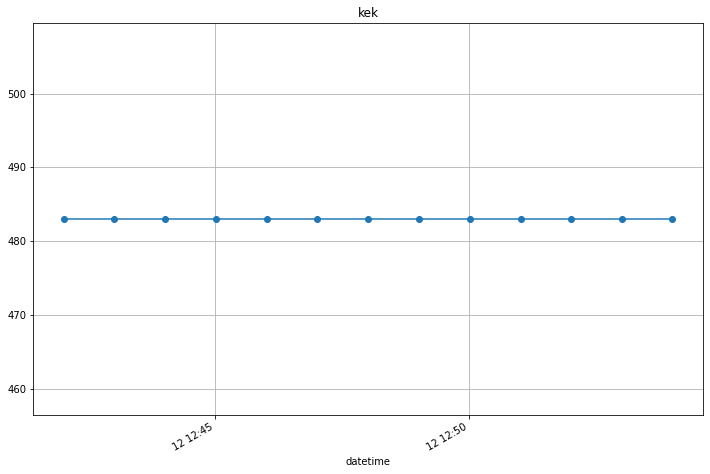

In [27]:
df3['MAPS'].plot(style='-o'
       , grid=True
       , title='kek'
       , figsize=(12, 8))
plt.show()

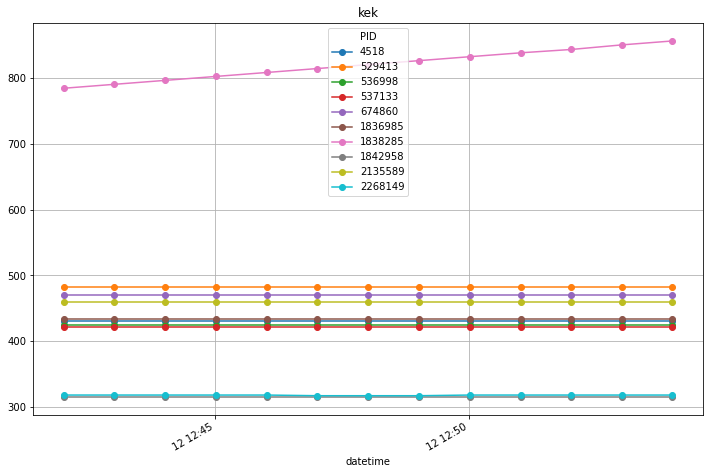

In [39]:
df2.pivot_table(index='datetime', columns='PID', values='MAPS').plot(style='-o'
       , grid=True
       , title='kek'
       , figsize=(12, 8))
plt.show()

In [37]:
df4=df2.pivot_table(index='datetime', columns='PID', values='MAPS')

In [38]:
df4.head()

PID,4518,529413,536998,537133,674860,1836985,1838285,1842958,2135589,2268149
datetime,,,,,,,,,,
2025-08-12 12:42:01,430,483,424,421,471,434,785,315,460,318
2025-08-12 12:43:01,430,483,424,421,471,434,791,315,460,318
2025-08-12 12:44:01,430,483,424,421,471,434,797,315,460,318
2025-08-12 12:45:01,430,483,424,421,471,434,803,315,460,318
2025-08-12 12:46:01,430,483,424,421,471,434,809,315,460,318
